# DimeNet++ Embedded Internal + Attention

Combines:
- Internal feature injection (Lowdin + EN into edge embeddings before message passing)
- Attention-weighted readout on the node-level output
- Spin conditioning
- All tuning wins

In [ ]:
# Install dependencies
!pip install -q torch==2.5.0 --index-url https://download.pytorch.org/whl/cu121
!pip install -q torch_geometric
!pip install -q torch_cluster torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-2.5.0+cu121.html
!pip install -q ase
!pip install -q --force-reinstall --no-deps "fairchem-core<2.0"
!pip install -q lmdb ase-db-backends e3nn hydra-core pymatgen submitit torchtnt

print("RESTART THE RUNTIME SESSION NOW")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 126.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 81.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 158.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 22.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 49.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 14.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 14.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 11.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.nn import DimeNetPlusPlus, radius_graph
from torch_geometric.loader import DataLoader
from torch_geometric.utils import scatter, softmax
from torch_geometric.typing import SparseTensor
from read_multi_ase_att import *
from extract_ab_att_emb import *

In [ ]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.clone() for k, v in model.state_dict().items()}

    def update(self, model):
        for k, v in model.state_dict().items():
            self.shadow[k] = self.decay * self.shadow[k] + (1 - self.decay) * v

    def apply(self, model):
        model.load_state_dict(self.shadow)


def triplets(edge_index, num_nodes):
    row, col = edge_index
    value = torch.arange(row.size(0), device=row.device)
    adj_t = SparseTensor(row=col, col=row, value=value,
                         sparse_sizes=(num_nodes, num_nodes))
    adj_t_row = adj_t[row]
    num_triplets = adj_t_row.set_value(None).sum(dim=1).to(torch.long)

    idx_i = col.repeat_interleave(num_triplets)
    idx_j = row.repeat_interleave(num_triplets)
    idx_k = adj_t_row.storage.col()
    mask = idx_i != idx_k
    idx_i, idx_j, idx_k = idx_i[mask], idx_j[mask], idx_k[mask]

    idx_kj = adj_t_row.storage.value()[mask]
    idx_ji = adj_t_row.storage.row()[mask]

    return col, row, idx_i, idx_j, idx_k, idx_kj, idx_ji


class DimeNetPP_EmbeddedAttention(nn.Module):
    """DimeNet++ with internal feature injection + attention readout + spin."""
    def __init__(self, hidden_channels=64, out_channels=2, num_blocks=4,
                 int_emb_size=64, basis_emb_size=8, out_emb_channels=128,
                 num_spherical=7, num_radial=6, cutoff=7.0,
                 extra_feat_dim=2, train_mean=None, train_std=None):
        super().__init__()
        self.cutoff = cutoff
        self.max_num_neighbors = 32

        self.dimenet = DimeNetPlusPlus(
            hidden_channels=hidden_channels,
            out_channels=hidden_channels,  # output per-node embeddings
            num_blocks=num_blocks,
            int_emb_size=int_emb_size,
            basis_emb_size=basis_emb_size,
            out_emb_channels=out_emb_channels,
            num_spherical=num_spherical,
            num_radial=num_radial,
            cutoff=cutoff,
        )

        # Internal feature injection
        self.feat_proj = nn.Linear(extra_feat_dim, hidden_channels)

        # Attention readout
        self.attn_gate = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.Tanh(),
            nn.Linear(hidden_channels, 1),
        )

        # Output projection
        self.output_proj = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.SiLU(),
            nn.Linear(hidden_channels, out_channels),
        )

        # Spin conditioning
        self.spin_proj = nn.Linear(1, out_channels)

        self.mean = train_mean
        self.std = train_std

    def forward(self, data):
        z, pos, batch = data.z, data.pos, data.batch
        extra_feat = data.extra_feat

        # Build graph
        edge_index = radius_graph(pos, r=self.cutoff, batch=batch,
                                  max_num_neighbors=self.max_num_neighbors)
        i, j, idx_i, idx_j, idx_k, idx_kj, idx_ji = triplets(
            edge_index, num_nodes=z.size(0))

        # Distances and angles
        dist = (pos[i] - pos[j]).pow(2).sum(dim=-1).sqrt()
        pos_jk = pos[idx_j] - pos[idx_k]
        pos_ij = pos[idx_i] - pos[idx_j]
        a = (pos_ij * pos_jk).sum(dim=-1)
        b = torch.linalg.cross(pos_ij, pos_jk).norm(dim=-1)
        angle = torch.atan2(b, a)

        # Basis functions
        rbf = self.dimenet.rbf(dist)
        sbf = self.dimenet.sbf(dist, angle, idx_kj)

        # Embedding block
        x = self.dimenet.emb(z, rbf, i, j)

        # === INJECT FEATURES into edge embeddings ===
        feat_node = self.feat_proj(extra_feat)
        x = x + feat_node[i] + feat_node[j]

        # Run output blocks + interaction blocks
        # Output blocks produce per-node representations
        P = self.dimenet.output_blocks[0](x, rbf, i, num_nodes=pos.size(0))

        for interaction_block, output_block in zip(
            self.dimenet.interaction_blocks, self.dimenet.output_blocks[1:]):
            x = interaction_block(x, rbf, sbf, idx_kj, idx_ji)
            P = P + output_block(x, rbf, i, num_nodes=pos.size(0))

        # === ATTENTION READOUT ===
        # P is [num_nodes, hidden_channels]
        attn_scores = self.attn_gate(P).squeeze(-1)
        attn_weights = softmax(attn_scores, batch)
        weighted = P * attn_weights.unsqueeze(-1)
        mol_repr = scatter(weighted, batch, dim=0, reduce='sum')

        # Project to output
        out = self.output_proj(mol_repr)

        # Spin conditioning
        spin = data.spin.unsqueeze(-1).float()
        out = out + self.spin_proj(spin)

        return out

In [ ]:
def train(model, loader):
    model.train()
    total_loss = 0
    loss_fn = nn.SmoothL1Loss(reduction='none')
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        pred = model(data)
        target = data.y.view(-1, 2)
        mask = data.y_mask.view(-1, 2)
        loss = (loss_fn(pred, target) * mask).sum() / mask.sum()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        ema.update(model)
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    loss_fn = nn.SmoothL1Loss(reduction='none')
    for data in loader:
        data = data.to(device)
        pred = model(data)
        target = data.y.view(-1, 2)
        mask = data.y_mask.view(-1, 2)
        loss = (loss_fn(pred, target) * mask).sum() / mask.sum()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def test(model, loader):
    model.eval()
    total_mae = 0
    total_mse = 0
    n = 0
    mean = model.mean.to(device)
    std = model.std.to(device)
    for data in loader:
        data = data.to(device)
        pred = model(data)
        target = data.y.view(-1, 2)
        mask = data.y_mask.view(-1, 2)
        pred_eV = (pred * std + mean) * mask
        target_eV = (target * std + mean) * mask
        total_mae += torch.abs(pred_eV - target_eV).sum().item()
        total_mse += ((pred_eV - target_eV) ** 2).sum().item()
        n += mask.sum().item()
    return total_mae / n, (total_mse / n) ** 0.5


def plot_losses(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss', linewidth=2)
    plt.plot(val_losses, label='Validation Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('DimeNet++ Embedded+Attention Alpha/Beta')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
bio_sample = process_file(file="/content/data0000.aselmdb", molecule_type="biomolecules", max_molecules=10000)
bio_data = get_data(bio_sample)
bio_train, bio_val, bio_test = split_data(bio_data)

train_mean, train_std = obtain_mean_std(bio_train)
bio_train = normalize_target(bio_train, train_mean, train_std)
bio_val = normalize_target(bio_val, train_mean, train_std)
bio_test = normalize_target(bio_test, train_mean, train_std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

print(f"Train: {len(bio_train)}, Val: {len(bio_val)}, Test: {len(bio_test)}")
print(f"Mean: {train_mean}, Std: {train_std}")

Processed 10000 molecules
Train: 6400, Val: 1600, Test: 2000
Mean: tensor([8.2471, 6.9315]), Std: tensor([2.0220, 2.0522])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DimeNetPP_EmbeddedAttention(
    hidden_channels=64,
    out_channels=2,
    num_blocks=4,
    int_emb_size=64,
    basis_emb_size=8,
    out_emb_channels=128,
    num_spherical=7,
    num_radial=6,
    cutoff=7.0,
    extra_feat_dim=2,
    train_mean=train_mean,
    train_std=train_std,
).to(device)

#optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=5e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
ema = EMA(model, decay=0.999)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 547,277


In [ ]:
epochs = 400
patience = 50
warmup_epochs = 5
base_lr = 5e-4
best_val = float('inf')
patience_counter = 0
best_state = None
train_losses, val_losses = [], []

for epoch in range(epochs):
    if epoch < warmup_epochs:
        warmup_lr = base_lr * (epoch + 1) / warmup_epochs
        for pg in optimizer.param_groups:
            pg['lr'] = warmup_lr

    t_loss = train(model, bio_train_loader)
    v_loss = evaluate(model, bio_val_loader)

    if epoch >= warmup_epochs:
        scheduler.step(v_loss)

    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if v_loss < best_val:
        best_val = v_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:03d} | Train: {t_loss:.4f} | Val: {v_loss:.4f} | LR: {lr:.1e} | Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Test both EMA and best checkpoint
ema.apply(model)
mae_ema, _ = test(model, bio_val_loader)
model.load_state_dict(best_state)
mae_best, _ = test(model, bio_val_loader)

if mae_ema < mae_best:
    ema.apply(model)
    print(f"Using EMA weights (val MAE: {mae_ema:.4f})")
else:
    print(f"Using best checkpoint (val MAE: {mae_best:.4f})")

print(f"Best Val Loss: {best_val:.4f}")

Epoch 001 | Train: 1.4029 | Val: 0.3134 | LR: 1.0e-04 | Patience: 0/50
Epoch 011 | Train: 0.1580 | Val: 0.1834 | LR: 5.0e-04 | Patience: 0/50
Epoch 021 | Train: 0.0903 | Val: 0.1443 | LR: 5.0e-04 | Patience: 0/50
Epoch 031 | Train: 0.0442 | Val: 0.1465 | LR: 5.0e-04 | Patience: 7/50
Epoch 041 | Train: 0.0671 | Val: 0.1558 | LR: 5.0e-04 | Patience: 6/50
Epoch 051 | Train: 0.0034 | Val: 0.1379 | LR: 2.5e-04 | Patience: 16/50
Epoch 061 | Train: 0.0007 | Val: 0.1392 | LR: 1.3e-04 | Patience: 26/50
Epoch 071 | Train: 0.0003 | Val: 0.1391 | LR: 6.3e-05 | Patience: 36/50
Epoch 081 | Train: 0.0001 | Val: 0.1392 | LR: 3.1e-05 | Patience: 46/50
Early stopping at epoch 85
Using EMA weights (val MAE: 0.7463)
Best Val Loss: 0.1344


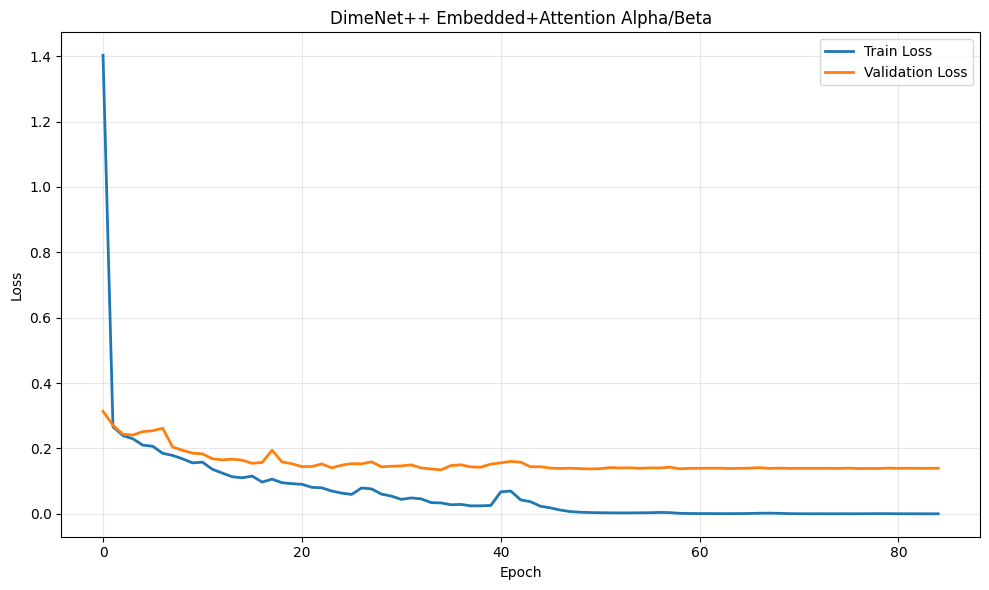

In [ ]:
plot_losses(train_losses, val_losses)

In [ ]:
mae, rmse = test(model, bio_test_loader)
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE: 0.7732
Test RMSE: 1.2079


Trying paper default out_emb_channels=256 instead of previous. might overfit on 10k but worth a shot. If overfits will try on 20k and that will be final.

Processed 10000 molecules
Train: 6400, Val: 1600, Test: 2000
Mean: tensor([8.2160, 6.7727]), Std: tensor([2.0535, 1.9845])
Model parameters: 1,368,397
Epoch 001 | Train: 4.7901 | Val: 0.3154 | LR: 1.0e-04 | Patience: 0/50
Epoch 011 | Train: 0.1541 | Val: 0.1993 | LR: 5.0e-04 | Patience: 1/50
Epoch 021 | Train: 0.1027 | Val: 0.1463 | LR: 5.0e-04 | Patience: 0/50
Epoch 031 | Train: 0.0614 | Val: 0.1692 | LR: 5.0e-04 | Patience: 2/50
Epoch 041 | Train: 0.0458 | Val: 0.1486 | LR: 5.0e-04 | Patience: 4/50
Epoch 051 | Train: 0.0062 | Val: 0.1275 | LR: 2.5e-04 | Patience: 0/50
Epoch 061 | Train: 0.0033 | Val: 0.1280 | LR: 2.5e-04 | Patience: 10/50
Epoch 071 | Train: 0.0005 | Val: 0.1279 | LR: 1.3e-04 | Patience: 6/50
Epoch 081 | Train: 0.0010 | Val: 0.1268 | LR: 1.3e-04 | Patience: 7/50
Epoch 091 | Train: 0.0000 | Val: 0.1265 | LR: 6.3e-05 | Patience: 17/50
Epoch 101 | Train: 0.0000 | Val: 0.1262 | LR: 3.1e-05 | Patience: 27/50
Epoch 111 | Train: 0.0000 | Val: 0.1263 | LR: 1.6e-05 | Patience:

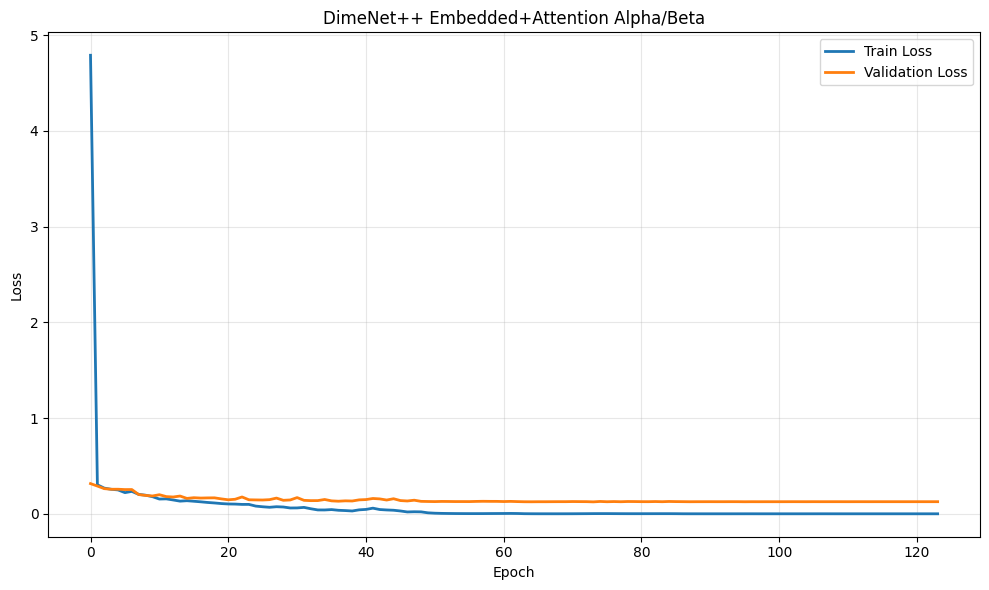

Test MAE: 0.7045
Test RMSE: 1.1379


In [ ]:
# === Run: Internal Embedded + Attention, 10k, out_emb_channels=256 ===

bio_sample = process_file(file="/content/data0000.aselmdb", molecule_type="biomolecules", max_molecules=10000)
bio_data = get_data(bio_sample)
bio_train, bio_val, bio_test = split_data(bio_data)

train_mean, train_std = obtain_mean_std(bio_train)
bio_train = normalize_target(bio_train, train_mean, train_std)
bio_val = normalize_target(bio_val, train_mean, train_std)
bio_test = normalize_target(bio_test, train_mean, train_std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

print(f"Train: {len(bio_train)}, Val: {len(bio_val)}, Test: {len(bio_test)}")
print(f"Mean: {train_mean}, Std: {train_std}")

model = DimeNetPP_EmbeddedAttention(
    hidden_channels=64,
    out_channels=2,
    num_blocks=4,
    int_emb_size=64,
    basis_emb_size=8,
    out_emb_channels=256,  # paper default
    num_spherical=7,
    num_radial=6,
    cutoff=7.0,
    extra_feat_dim=2,
    train_mean=train_mean,
    train_std=train_std,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=5e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
ema = EMA(model, decay=0.999)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

epochs = 400
patience = 50
warmup_epochs = 5
base_lr = 5e-4
best_val = float('inf')
patience_counter = 0
best_state = None
train_losses, val_losses = [], []

for epoch in range(epochs):
    if epoch < warmup_epochs:
        warmup_lr = base_lr * (epoch + 1) / warmup_epochs
        for pg in optimizer.param_groups:
            pg['lr'] = warmup_lr

    t_loss = train(model, bio_train_loader)
    v_loss = evaluate(model, bio_val_loader)

    if epoch >= warmup_epochs:
        scheduler.step(v_loss)

    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if v_loss < best_val:
        best_val = v_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:03d} | Train: {t_loss:.4f} | Val: {v_loss:.4f} | LR: {lr:.1e} | Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

ema.apply(model)
mae_ema, _ = test(model, bio_val_loader)
model.load_state_dict(best_state)
mae_best, _ = test(model, bio_val_loader)

if mae_ema < mae_best:
    ema.apply(model)
    print(f"Using EMA weights (val MAE: {mae_ema:.4f})")
else:
    print(f"Using best checkpoint (val MAE: {mae_best:.4f})")

print(f"Best Val Loss: {best_val:.4f}")

plot_losses(train_losses, val_losses)

mae, rmse = test(model, bio_test_loader)
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Processed 20000 molecules
Train: 12800, Val: 3200, Test: 4000
Mean: tensor([8.2037, 6.7670]), Std: tensor([2.0504, 2.0856])
Model parameters: 1,368,397
Epoch 001 | Train: 1.0718 | Val: 0.2906 | LR: 1.0e-04 | Patience: 0/50
Epoch 011 | Train: 0.1291 | Val: 0.1241 | LR: 5.0e-04 | Patience: 0/50
Epoch 021 | Train: 0.0865 | Val: 0.1227 | LR: 5.0e-04 | Patience: 2/50
Epoch 031 | Train: 0.0561 | Val: 0.1022 | LR: 5.0e-04 | Patience: 0/50
Epoch 041 | Train: 0.0553 | Val: 0.1076 | LR: 5.0e-04 | Patience: 5/50
Epoch 051 | Train: 0.0290 | Val: 0.1006 | LR: 5.0e-04 | Patience: 8/50
Epoch 061 | Train: 0.0047 | Val: 0.0946 | LR: 2.5e-04 | Patience: 5/50
Epoch 071 | Train: 0.0006 | Val: 0.0921 | LR: 1.3e-04 | Patience: 1/50
Epoch 081 | Train: 0.0010 | Val: 0.0917 | LR: 6.3e-05 | Patience: 11/50
Epoch 091 | Train: 0.0004 | Val: 0.0921 | LR: 6.3e-05 | Patience: 21/50
Epoch 101 | Train: 0.0001 | Val: 0.0918 | LR: 3.1e-05 | Patience: 31/50
Epoch 111 | Train: 0.0000 | Val: 0.0917 | LR: 1.6e-05 | Patience

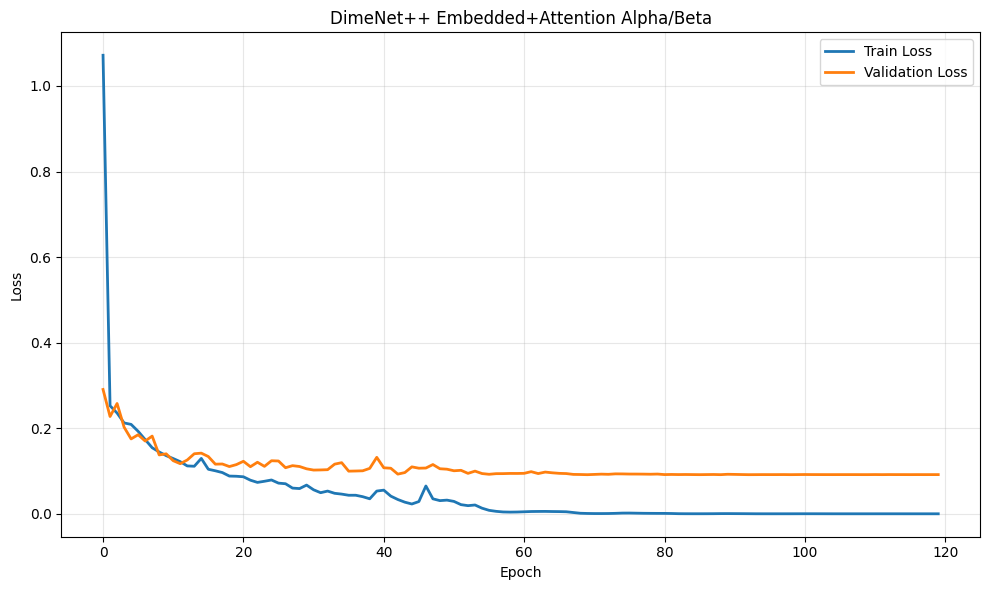

Test MAE: 0.6112
Test RMSE: 0.9933


In [ ]:
# === Final Run: Internal Embedded + Attention, 20k, out_emb_channels=256 ===

bio_sample = process_file(file=["/content/data0000.aselmdb", "/content/data0001.aselmdb"], molecule_type="biomolecules", max_molecules=20000)
bio_data = get_data(bio_sample)
bio_train, bio_val, bio_test = split_data(bio_data)

train_mean, train_std = obtain_mean_std(bio_train)
bio_train = normalize_target(bio_train, train_mean, train_std)
bio_val = normalize_target(bio_val, train_mean, train_std)
bio_test = normalize_target(bio_test, train_mean, train_std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

print(f"Train: {len(bio_train)}, Val: {len(bio_val)}, Test: {len(bio_test)}")
print(f"Mean: {train_mean}, Std: {train_std}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DimeNetPP_EmbeddedAttention(
    hidden_channels=64,
    out_channels=2,
    num_blocks=4,
    int_emb_size=64,
    basis_emb_size=8,
    out_emb_channels=256,
    num_spherical=7,
    num_radial=6,
    cutoff=7.0,
    extra_feat_dim=2,
    train_mean=train_mean,
    train_std=train_std,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=5e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
ema = EMA(model, decay=0.999)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

epochs = 400
patience = 50
warmup_epochs = 5
base_lr = 5e-4
best_val = float('inf')
patience_counter = 0
best_state = None
train_losses, val_losses = [], []

for epoch in range(epochs):
    if epoch < warmup_epochs:
        warmup_lr = base_lr * (epoch + 1) / warmup_epochs
        for pg in optimizer.param_groups:
            pg['lr'] = warmup_lr

    t_loss = train(model, bio_train_loader)
    v_loss = evaluate(model, bio_val_loader)

    if epoch >= warmup_epochs:
        scheduler.step(v_loss)

    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if v_loss < best_val:
        best_val = v_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:03d} | Train: {t_loss:.4f} | Val: {v_loss:.4f} | LR: {lr:.1e} | Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

ema.apply(model)
mae_ema, _ = test(model, bio_val_loader)
model.load_state_dict(best_state)
mae_best, _ = test(model, bio_val_loader)

if mae_ema < mae_best:
    ema.apply(model)
    print(f"Using EMA weights (val MAE: {mae_ema:.4f})")
else:
    print(f"Using best checkpoint (val MAE: {mae_best:.4f})")

print(f"Best Val Loss: {best_val:.4f}")

plot_losses(train_losses, val_losses)

mae, rmse = test(model, bio_test_loader)
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

In [ ]:
### Trying on 30k bc am curious - more data needed to lessen gap??

Processed 30000 molecules
Train: 19200, Val: 4800, Test: 6000
Mean: tensor([8.2141, 6.7411]), Std: tensor([2.0506, 2.1403])
Model parameters: 1,368,397
Epoch 001 | Train: 0.4880 | Val: 0.2378 | LR: 1.0e-04 | Patience: 0/50
Epoch 011 | Train: 0.1058 | Val: 0.1110 | LR: 5.0e-04 | Patience: 0/50
Epoch 021 | Train: 0.0621 | Val: 0.0915 | LR: 5.0e-04 | Patience: 2/50
Epoch 031 | Train: 0.0397 | Val: 0.0901 | LR: 5.0e-04 | Patience: 5/50
Epoch 041 | Train: 0.0105 | Val: 0.0768 | LR: 2.5e-04 | Patience: 2/50
Epoch 051 | Train: 0.0064 | Val: 0.0745 | LR: 2.5e-04 | Patience: 3/50
Epoch 061 | Train: 0.0014 | Val: 0.0719 | LR: 1.3e-04 | Patience: 0/50
Epoch 071 | Train: 0.0014 | Val: 0.0717 | LR: 1.3e-04 | Patience: 5/50
Epoch 081 | Train: 0.0011 | Val: 0.0715 | LR: 1.3e-04 | Patience: 4/50
Epoch 091 | Train: 0.0011 | Val: 0.0704 | LR: 1.3e-04 | Patience: 9/50
Epoch 101 | Train: 0.0010 | Val: 0.0733 | LR: 1.3e-04 | Patience: 9/50
Epoch 111 | Train: 0.0004 | Val: 0.0706 | LR: 6.3e-05 | Patience: 1

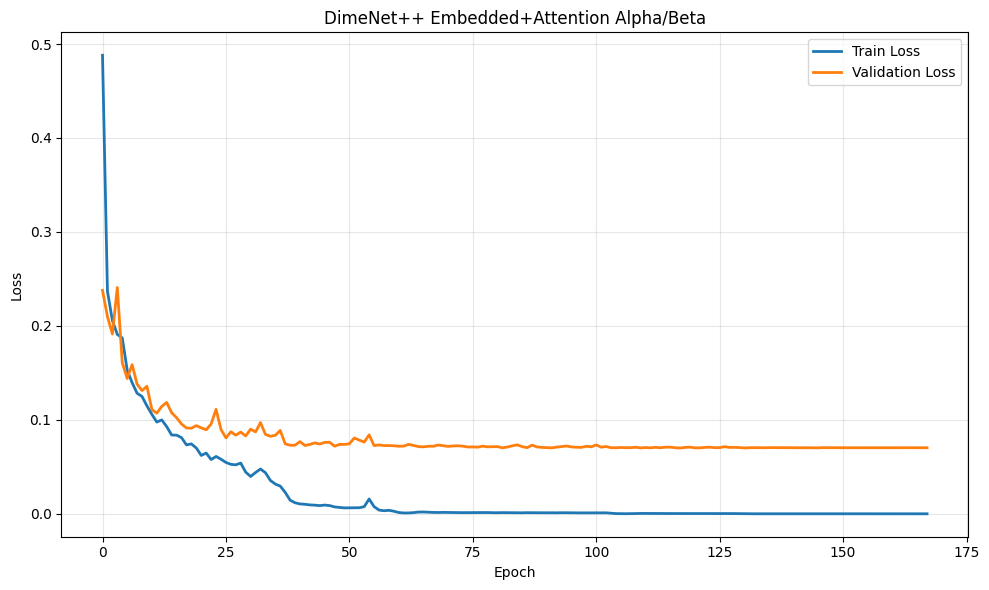

Test MAE: 0.5233
Test RMSE: 0.8327


In [ ]:
# === Final Run: Internal Embedded + Attention, 30k, out_emb_channels=256 ===

bio_sample = process_file(file=["/content/data0000.aselmdb", "/content/data0001.aselmdb", "/content/data0002.aselmdb"], molecule_type="biomolecules", max_molecules=30000)
bio_data = get_data(bio_sample)
bio_train, bio_val, bio_test = split_data(bio_data)

train_mean, train_std = obtain_mean_std(bio_train)
bio_train = normalize_target(bio_train, train_mean, train_std)
bio_val = normalize_target(bio_val, train_mean, train_std)
bio_test = normalize_target(bio_test, train_mean, train_std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

print(f"Train: {len(bio_train)}, Val: {len(bio_val)}, Test: {len(bio_test)}")
print(f"Mean: {train_mean}, Std: {train_std}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DimeNetPP_EmbeddedAttention(
    hidden_channels=64,
    out_channels=2,
    num_blocks=4,
    int_emb_size=64,
    basis_emb_size=8,
    out_emb_channels=256,
    num_spherical=7,
    num_radial=6,
    cutoff=7.0,
    extra_feat_dim=2,
    train_mean=train_mean,
    train_std=train_std,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=5e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
ema = EMA(model, decay=0.999)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

epochs = 400
patience = 50
warmup_epochs = 5
base_lr = 5e-4
best_val = float('inf')
patience_counter = 0
best_state = None
train_losses, val_losses = [], []

for epoch in range(epochs):
    if epoch < warmup_epochs:
        warmup_lr = base_lr * (epoch + 1) / warmup_epochs
        for pg in optimizer.param_groups:
            pg['lr'] = warmup_lr

    t_loss = train(model, bio_train_loader)
    v_loss = evaluate(model, bio_val_loader)

    if epoch >= warmup_epochs:
        scheduler.step(v_loss)

    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if v_loss < best_val:
        best_val = v_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:03d} | Train: {t_loss:.4f} | Val: {v_loss:.4f} | LR: {lr:.1e} | Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

ema.apply(model)
mae_ema, _ = test(model, bio_val_loader)
model.load_state_dict(best_state)
mae_best, _ = test(model, bio_val_loader)

if mae_ema < mae_best:
    ema.apply(model)
    print(f"Using EMA weights (val MAE: {mae_ema:.4f})")
else:
    print(f"Using best checkpoint (val MAE: {mae_best:.4f})")

print(f"Best Val Loss: {best_val:.4f}")

plot_losses(train_losses, val_losses)

mae, rmse = test(model, bio_test_loader)
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")